In [6]:
!git clone https://github.com/KirillKulaev/DeepFit.git
!pip install ./DeepFit

Cloning into 'DeepFit'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 278 (delta 3), reused 6 (delta 2), pack-reused 267 (from 1)
Receiving objects: 100% (278/278), 19.59 MiB | 8.62 MiB/s, done.
Resolving deltas: 100% (87/87), done.
Processing ./DeepFit
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.1/450.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00
  Created wheel for deepfit_package: filename=deepfit_package-0.1.0-py3-none-any.whl size=590135 sha256=11c9c017cc278a0b2b68d8a93fd38825e8c95c673fc51cd11de9c2d8962bd3c8
  Stored in directory: /tmp/pip-ephem-wheel-cache-rbgxh7qn/wheels/d3/f7/42/fcf242b55fdbd65535a3f0947dc0fde90fc2a0f07a483ea1e4
Successfully built deepfit_package


In [15]:
! pip install py3Dmol

In [ ]:
! chmod +x /content/DeepFit/examples/xtb

### Setup NN

In [ ]:
# import neural network
import deepfit_package
from deepfit_package import Net, Structure, DeepFit
model = Net(device='cpu').to('cpu')

### Load experimental spectrum (in $k^2\chi(k)$ representation)

In [9]:
# Read spectrum
import numpy as np
with open('/content/DeepFit/examples/TEOA.txt', 'r') as f:
    file = f.read()
    k = np.array([float(i.split()[0]) for i in file.splitlines()[1:]])
    chik2 = np.array([float(i.split()[1]) for i in file.splitlines()[1:]])
# interpolate spectra
spectrum = np.interp(model.k.cpu(), k, chik2)

Interpolation of spectrum for deepfit compatibility

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3810527186.py:6: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(k, chik2, 'o', markersize=3, c='lime'), plt.xlabel('wavenumber, $k$'), plt.ylabel('$k^2\chi(k)$'), plt.legend(['$k^2\chi(k)$', 'interp. $k^2\chi(k)$'])
/tmp/ipython-input-3810527186.py:6: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(k, chik2, 'o', markersize=3, c='lime'), plt.xlabel('wavenumber, $k$'), plt.ylabel('$k^2\chi(k)$'), plt.legend(['$k^2\chi(k)$', 'interp. $k^2\chi(k)$'])
/tmp/ipython-input-3810527186.py:6: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(k, chik2, 'o', markersize=3, c='lime'), plt.xlabel('wavenumber, $k$'), plt.ylabel('$k^2\chi(k)$'), plt.legend(['$k^2\chi(k)

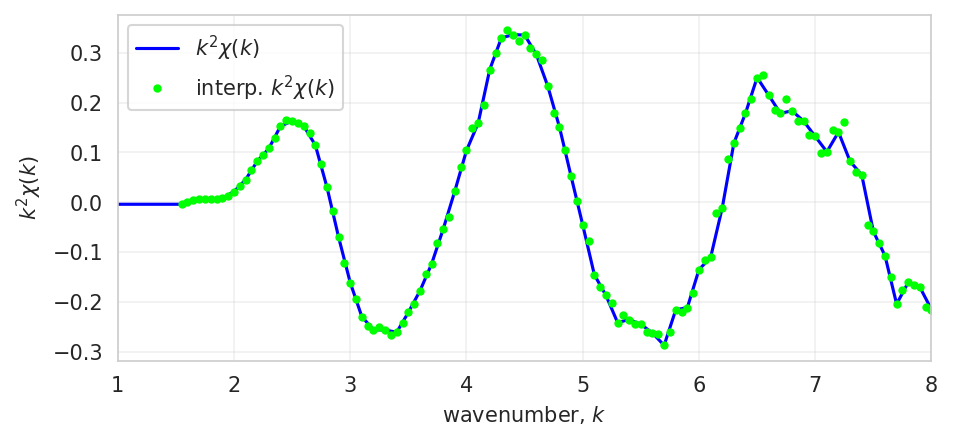

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(7, 3), dpi=150), plt.grid(True, alpha=0.3)
plt.plot(model.k.cpu().numpy(), spectrum, c='blue'), plt.xlim(1, 8)
plt.plot(k, chik2, 'o', markersize=3, c='lime'), plt.xlabel('wavenumber, $k$'), plt.ylabel('$k^2\chi(k)$'), plt.legend(['$k^2\chi(k)$', 'interp. $k^2\chi(k)$'])
None

### Structure Optimization

In [16]:
import py3Dmol
def view(xyz):
    xyz = str(len(xyz.splitlines()))+'\n\n'+xyz
    xyzview = py3Dmol.view(width=400,height=400)
    xyzview.addModel(xyz,'xyz') #{'vibrate': {'frames':10,'amplitude':1}}
    xyzview.setStyle({"stick": {}, "sphere": {"scale": 0.3}})
    xyzview.setBackgroundColor('0xeeeeee')
    xyzview.animate({'loop': 'backAndForth'})
    xyzview.zoomTo()
    xyzview.show()

In [38]:
name = '/content/DeepFit/examples/rh_dataset_geometries/4_TEOA2_aka4_3_0_3.xyz'
xyz = '\n'.join(open(name).read().splitlines()[2:])

In [39]:
view(xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [40]:
struct = Structure(xyz, absorber='Rh', charge=0, device='cpu')

deepfit = DeepFit(struct,
                  spectrum,
                  model=model,
                  path2xtb='/content/DeepFit/examples/xtb',
                  step_speed=0.125,
                  forces_coeff=2.5,
                  fit_edges=(0., 8.))

fitted_structure, fitted_spectra = deepfit.run(verbose=0, num_steps=200, final_geomopt_steps=10, distance_weightning=True)
fitted_xyz = deepfit.struct2xyz(fitted_structure)

Fitting of the structure


100%|██████████| 200/200 [01:40<00:00,  1.99it/s]


Structure changing

In [41]:
viewer = py3Dmol.view(width=400,height=400)
viewer.addModelsAsFrames('\n'.join([str(len(i.splitlines()))+'\n\n'+i for i in deepfit.history]), 'xyz')
viewer.setStyle({"stick": {"scale": 1.}, "sphere": {"scale": 0.3}})
viewer.setBackgroundColor('0xeeeeee')
viewer.zoomTo()
viewer.animate({'loop': "forward"})
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Spectrum changing

In [42]:
import torch
import plotly.graph_objects as go
from deepfit_package import get_normed_spectra
device = 'cpu'
normed_spectrum = get_normed_spectra(torch.tensor(spectrum, dtype=torch.float32), model.k.cpu())
history = [get_normed_spectra(torch.tensor(sp, dtype=torch.float32, device=device), model.k).cpu() for sp in deepfit.history_spec]

fig = go.Figure(
    data=[go.Scatter(x=model.k.cpu().numpy(), y=history[0], line=dict(color='blue', width=2), name='Predicted k²χ(k)'),
          go.Scatter(x=model.k.cpu().numpy(), y=normed_spectrum, line=dict(color='lime', width=2), name='Experimental k²χ(k)')],
    layout=go.Layout(
        xaxis=dict(range=[1.5, 8], autorange=False, title='wavenumber, (Å⁻¹)'),
        yaxis=dict(range=[-0.3, 0.4], autorange=False, title='k²χ(k)'),
        width=1200,
        height=600,
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play",
                          method="animate",
                          args = [None, {"frame": {"duration": 20, "redraw": False},
                                "fromcurrent": True, "transition": {"duration": 10}}])])],
        template='plotly_white'
    ),
    frames=[go.Frame(data=[go.Scatter(x=model.k.cpu().numpy(), y=sp)]) for sp in history]
)

fig.show()

### Run screening with DeepFit

Cycle over dataset of Rh structures and run DeepFit structure optimization

In [ ]:
import os
history = dict()
for name in os.listdir('rh_dataset_geometries'):
    xyz = '\n'.join(open(f'rh_dataset_geometries/{name}').read().splitlines()[2:])
    struct = Structure(xyz, absorber='Rh', charge=0, device='cpu')

    deepfit = DeepFit(struct,
                      spectrum,
                      model=model,
                      path2xtb='/content/DeepFit/examples/xtb',
                      step_speed=0.125,
                      forces_coeff=2.5,
                      fit_edges=(1.5, 8))

    fitted_structure, fitted_spectra = deepfit.run(verbose=0, num_steps=200, final_geomopt_steps=10, distance_weightning=True)
    fitted_xyz = deepfit.struct2xyz(fitted_structure)
    forces_norm = deepfit.eval_stability(xyz, absorber='Rh')
    history[name] = dict(energy=deepfit.history_energy, sp=deepfit.history_sp_loss, fitted_spectra=fitted_spectra, forces_norm=forces_norm, fitted_xyz=fitted_xyz)


Visualize the fits of best and another 3 structures

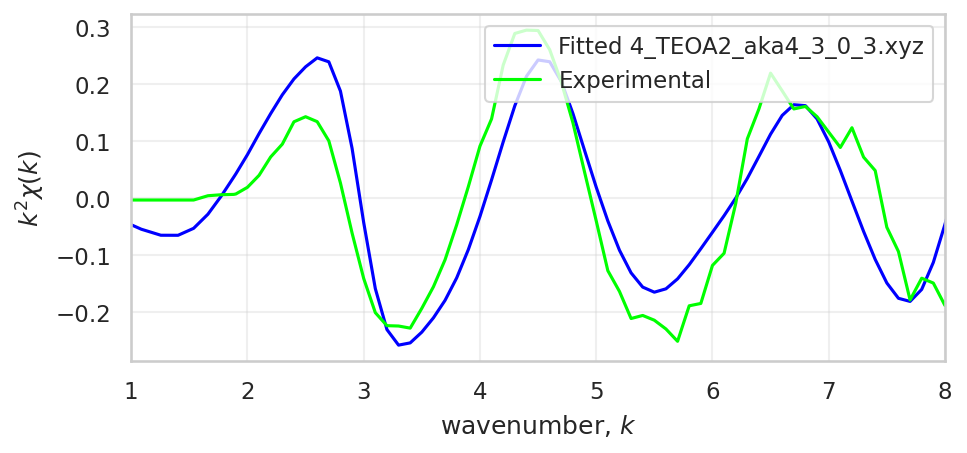

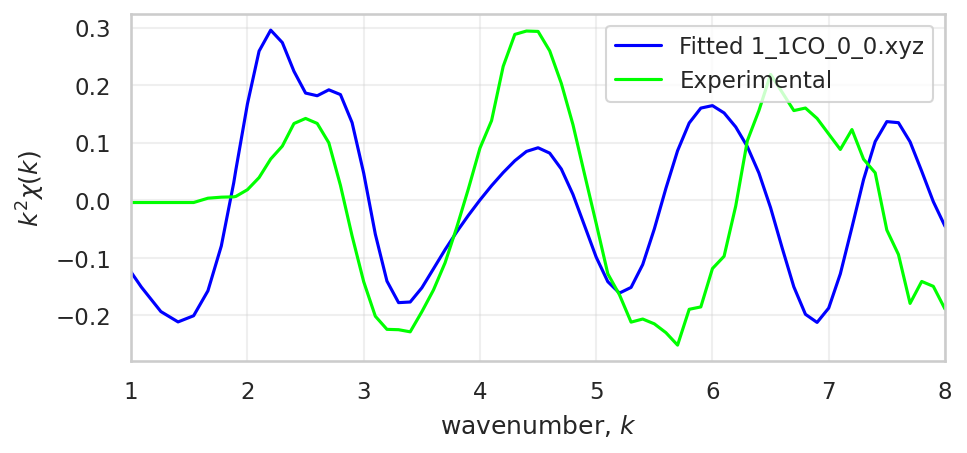

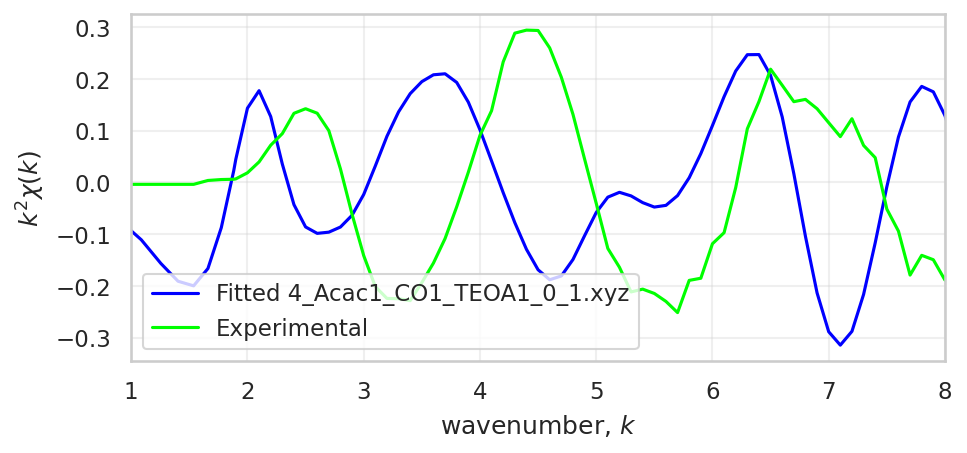

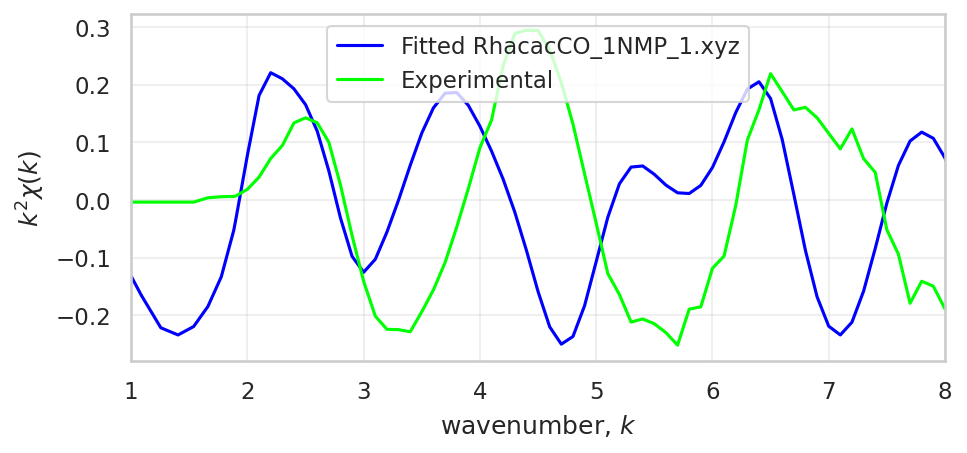

In [ ]:
import torch
names = list(history.keys())
res = np.array([history[i]['sp'][-1] for i in names])
names2show = [names[n] for n in [res.argmin(), 0, 15, 20]]
for name in names2show:
    plt.figure(figsize=(7, 3), dpi=150), plt.grid(True, alpha=0.3), plt.xlim(1, 8), plt.ylabel('$k^2\chi(k)$'), plt.xlabel('wavenumber, $k$')
    pred = deepfit_package.get_normed_spectra(torch.tensor(history[name]['fitted_spectra'][0], dtype=torch.float32), model.k.cpu())
    ref = deepfit_package.get_normed_spectra(torch.tensor(spectrum, dtype=torch.float32), model.k.cpu())
    plt.plot(model.k.cpu(), pred, c='blue')
    plt.plot(model.k.cpu(), ref, c='lime')
    plt.legend([f'Fitted {name}', 'Experimental']), plt.show()
None

Visualize results of fitting in terms of norm of forces $\nabla F$ (in first coordination shell) and spectra deviation $D$

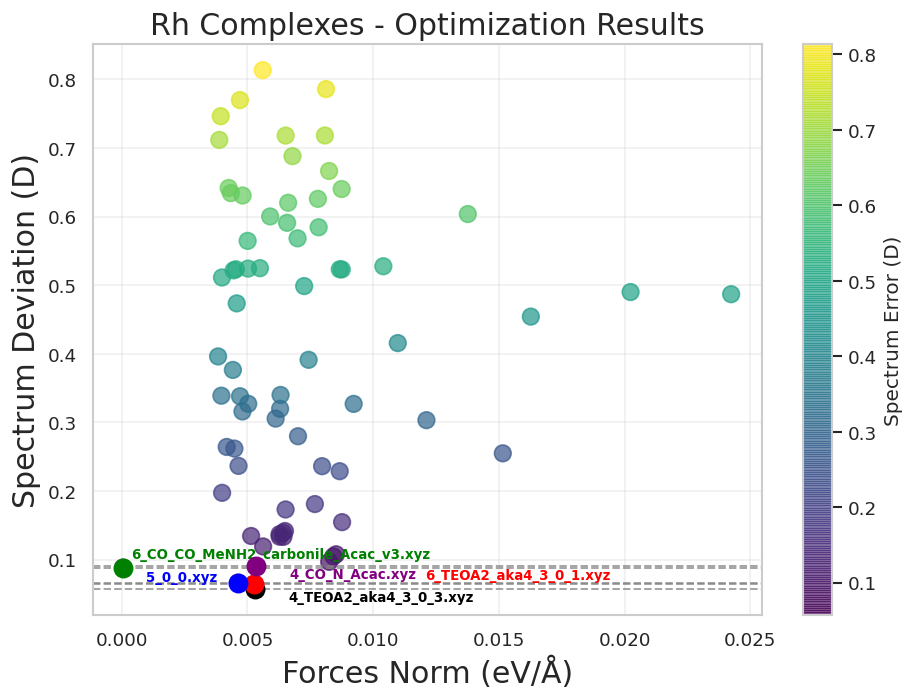

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

names = []
forces_norms = []
spectrum_deviations = []

for name, data in history.items():
    names.append(name)
    forces_norms.append(data['forces_norm'])
    spectrum_deviations.append(data['sp'][-1] if data['sp'] else 0)

df = pd.DataFrame({'Name': names, 'Forces_Norm': forces_norms, 'Spectrum_Deviation': spectrum_deviations})

scatter = ax.scatter(df['Forces_Norm'], df['Spectrum_Deviation'], c=df['Spectrum_Deviation'], cmap='viridis', s=100, alpha=0.7)
d = np.array([1e-3, 6.5e-3, -4e-3, 0., 1e-3])
d2 = np.array([-3e-2, -5e-3, -1e-2, 1e-3, -3e-2])
colors = ['black', 'red', 'blue', 'green', 'purple']
for i, (idx, row) in enumerate(df.nsmallest(5, 'Spectrum_Deviation').iterrows()):
    ax.scatter(row['Forces_Norm'], row['Spectrum_Deviation'], color=colors[i], s=120, zorder=5)
    ax.axhline(y=row['Spectrum_Deviation'], color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.annotate(row['Name'], (row['Forces_Norm']+d[i], row['Spectrum_Deviation']+d2[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, fontweight='bold', color=colors[i])

ax.set_xlabel('Forces Norm (eV/Å)', fontsize=18)
ax.set_ylabel('Spectrum Deviation (D)', fontsize=18)
ax.set_title("Rh Complexes - Optimization Results", fontsize=18)
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax).set_label('Spectrum Error (D)', fontsize=12)
plt.tight_layout()
plt.show()

Two best fits are similar structures

In [ ]:
view(history['4_TEOA2_aka4_3_0_3.xyz']['fitted_xyz'])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
view(history['6_TEOA2_aka4_3_0_1.xyz']['fitted_xyz'])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.